In [14]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


# VISUALIZATION HELPER


plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

sns.set_theme(style="whitegrid")

cmap = plt.cm.magma

city_translation = {
    "杭州市": "Ханчжоу",
    "上海市": "Шанхай",
    "重庆市": "Чунцін"
}

def get_magma_colors(n):
    return cmap(np.linspace(0.25, 0.85, n))

#  LOAD DATASET

In [16]:
df = pd.read_csv("delivery_five_cities.csv")

df = df.drop_duplicates()

df["city_ua"] = df["from_city_name"].map(city_translation)

print("Розмір dataset:", df.shape)
print("Кількість дублікатів після очищення:", df.duplicated().sum())
display(df.head())

Розмір dataset: (472419, 16)
Кількість дублікатів після очищення: 0


,order_id,from_dipan_id,from_city_name,delivery_user_id,poi_lng,poi_lat,aoi_id,typecode,receipt_time,receipt_lng,receipt_lat,sign_time,sign_lng,sign_lat,ds,city_ua
0,687227b4d0c733049b16ccd566db6e01,08331170e24742ba7a3938f5b34ff24d,上海市,18ff78d2069125937a847fb701a9db6c,1.056351e+07,-7.458321e+06,e0581ca18e7ca371a9869e041cb09075,4602b38053ece07a9ca5153f1df2e404,03-18 13:35:00,1.056160e+07,-7.457998e+06,03-18 14:51:00,NaN,NaN,318,Шанхай
1,55be8cdf1270526231c9ba3387f51b54,c5ac5ba99801aa6b85ba473d9260512b,重庆市,df0b594618d1ba6f619e4e7dd034447c,8.899874e+06,-7.684936e+06,9c0f96ff01a71477334ef563001abc72,203ac3454d75e02ebb0a3c6f51d735e4,03-18 08:32:00,8.900992e+06,-7.686103e+06,03-18 14:33:00,NaN,NaN,318,Чунцін
2,ee46cae9ba2c002451af3c6fbcb49410,2129bfb99a2f6c11000c0ecbf1a5f3f6,上海市,05cceaaa5db96756294dd6d573fd865d,1.058131e+07,-7.467397e+06,4de9bf7f155046e7d0fd400672ab9cf3,203ac3454d75e02ebb0a3c6f51d735e4,03-18 13:02:00,1.058124e+07,-7.467607e+06,03-18 15:34:00,NaN,NaN,318,Шанхай
3,38912be86c83138901b5e26398832be7,08331170e24742ba7a3938f5b34ff24d,上海市,f29e97ef8398477abb72b852b16c91c0,1.056273e+07,-7.456804e+06,fe48cde9b33e2308641d985f8a701c7e,203ac3454d75e02ebb0a3c6f51d735e4,03-18 12:11:00,1.056160e+07,-7.457997e+06,03-18 14:08:00,NaN,NaN,318,Шанхай
4,2b83e2ba16714fee357694964d0e7e41,4fe96250270c2e17a28016a5fba4bc4a,杭州市,1d00e6f2308aad233f0179aac63aa23d,1.044847e+07,-7.587086e+06,a7d4de5484ca867fe453976ba9fee424,4602b38053ece07a9ca5153f1df2e404,03-18 07:28:00,1.044791e+07,-7.586259e+06,03-20 12:40:00,NaN,NaN,318,Ханчжоу


# Опис колонок dataset LaDe (delivery_five_cities.csv)

| Назва колонки | Опис | Українською |
|---|---|---|
| order_id | Unique order identifier | Унікальний ідентифікатор замовлення |
| from_dipan_id | Distribution station identifier | Ідентифікатор пункту розподілу / складу |
| from_city_name | City name | Назва міста |
| delivery_user_id | Courier identifier | Ідентифікатор кур’єра |
| poi_lng | Longitude of delivery point | Довгота точки доставки |
| poi_lat | Latitude of delivery point | Широта точки доставки |
| aoi_id | Area identifier | Ідентифікатор району / зони доставки |
| typecode | Delivery area type code | Код типу зони доставки |
| receipt_time | Order receipt time | Час отримання замовлення |
| receipt_lng | Longitude of receipt point | Довгота точки отримання замовлення |
| receipt_lat | Latitude of receipt point | Широта точки отримання замовлення |
| sign_time | Delivery completion time | Час підтвердження доставки |
| sign_lng | Longitude of delivery completion point | Довгота точки завершення доставки |
| sign_lat | Latitude of delivery completion point | Широта точки завершення доставки |
| ds | Delivery date | Дата доставки |

скільки міст:

In [17]:
print(df["from_city_name"].value_counts())

from_city_name
杭州市    185589
上海市    165583
重庆市    121247
Name: count, dtype: int64


# Назви міст у dataset LaDe

| Оригінальна назва | Українською | Англійською |  Кількість доставок |
|---|---|---|---|
| 杭州市 | Ханчжоу | Hangzhou | 185 589 |
| 上海市 | Шанхай | Shanghai |  165 583 |
| 重庆市 | Чунцін | Chongqing | 121 247 |


Для проведення аналізу транспортно-технологічного процесу доставки тарно-штучних вантажів у міському сполученні було використано публічну базу даних LaDe (Last-mile Delivery Dataset).

Dataset містить інформацію про процеси міської доставки в декількох містах Китаю та включає дані про маршрути доставки, часові параметри, координати точок доставки, кур’єрів та замовлення.

База даних містить 472 419 записів та 14 змінних, серед яких:

ідентифікатор замовлення;
місто доставки;
координати;
час отримання замовлення;
інформація про кур’єра;
дата доставки.

Використання даного dataset дозволяє виконати аналіз ефективності процесу доставки, дослідити часові характеристики маршрутів та оцінити логістичні KPI міської доставки.


#  BASIC DATASET INFORMATION

In [18]:
basic_info = pd.DataFrame({
    "Показник": [
        "Кількість рядків",
        "Кількість колонок",
        "Обсяг пам’яті, MB",
        "Кількість унікальних замовлень",
        "Кількість унікальних кур’єрів",
        "Кількість міст"
    ],
    "Значення": [
        df.shape[0],
        df.shape[1],
        round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        df["order_id"].nunique(),
        df["delivery_user_id"].nunique(),
        df["city_ua"].nunique()
    ]
})

display(basic_info)

,Показник,Значення
0,Кількість рядків,472419.00
1,Кількість колонок,16.00
2,"Обсяг пам’яті, MB",343.05
3,Кількість унікальних замовлень,472419.00
4,Кількість унікальних кур’єрів,1870.00
5,Кількість міст,3.00



#  MISSING VALUES

In [19]:
missing_values = (
    df.isnull().sum()
    .reset_index()
    .rename(columns={"index": "Колонка", 0: "Кількість пропусків"})
)

missing_values["Частка пропусків, %"] = (
    missing_values["Кількість пропусків"] / len(df) * 100
).round(2)

display(missing_values)

,Колонка,Кількість пропусків,"Частка пропусків, %"
0,order_id,0,0.00
1,from_dipan_id,0,0.00
2,from_city_name,0,0.00
3,delivery_user_id,0,0.00
4,poi_lng,0,0.00
5,poi_lat,0,0.00
6,aoi_id,0,0.00
7,typecode,1360,0.29
8,receipt_time,0,0.00
9,receipt_lng,0,0.00


# 4. DELIVERIES BY CITY

,Місто,Кількість доставок
0,Ханчжоу,185589
1,Шанхай,165583
2,Чунцін,121247


C:\Users\Dell\AppData\Local\Temp\ipykernel_12852\3093658360.py:14: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


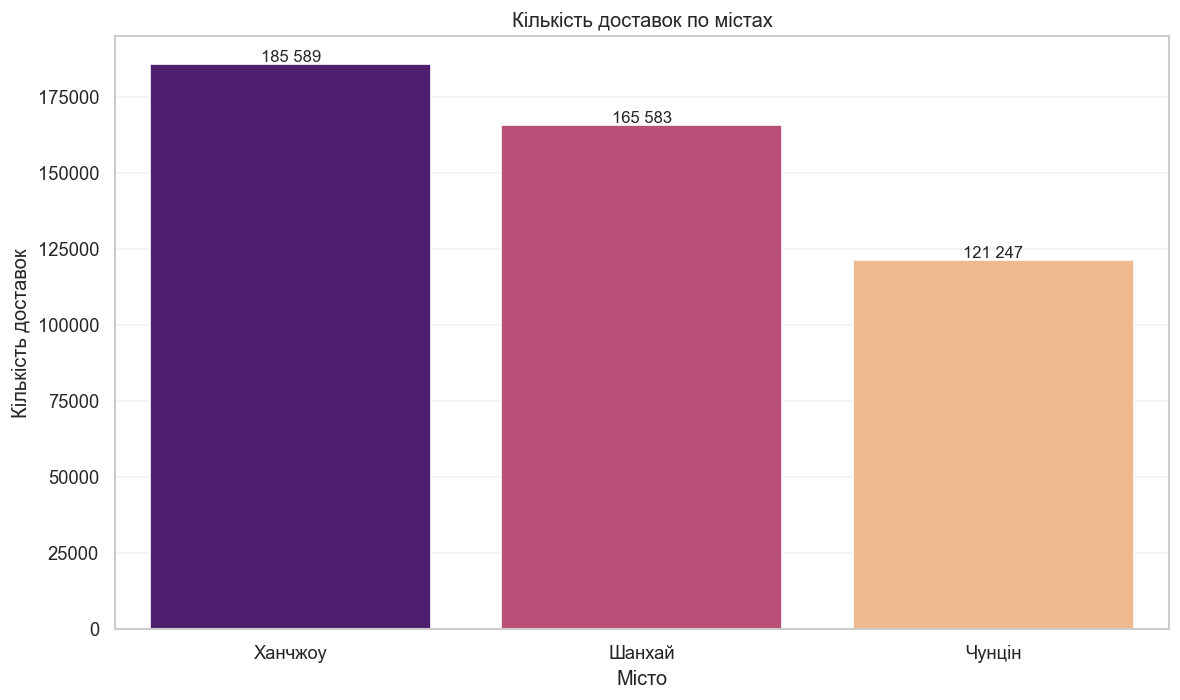

In [20]:

city_orders = (
    df["city_ua"]
    .value_counts()
    .reset_index()
)

city_orders.columns = ["Місто", "Кількість доставок"]

display(city_orders)

plt.figure()
colors = get_magma_colors(len(city_orders))

sns.barplot(
    data=city_orders,
    x="Місто",
    y="Кількість доставок",
    hue="Місто",
    palette=colors,
    legend=False
)

plt.title("Кількість доставок по містах")
plt.xlabel("Місто")
plt.ylabel("Кількість доставок")

for index, row in city_orders.iterrows():
    plt.text(
        index,
        row["Кількість доставок"],
        f"{row['Кількість доставок']:,}".replace(",", " "),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Показує масштаб операційної активності та навантаження на міську систему доставки. Бажано окремо зазначити, що це ще не показник ефективності, а лише показник обсягу.

Висновок

Найбільша кількість доставок спостерігається у місті Ханчжоу — 185 589 доставок.
У Шанхаї було виконано 165 583 доставки, а найменше замовлень зафіксовано у Чунціні — 121 247.

Це свідчить про те, що найбільше навантаження на систему доставки припадає саме на Ханчжоу та Шанхай.


# 5. DELIVERY DURATION CALCULATION

In [21]:
df["receipt_datetime"] = pd.to_datetime(
    "2024-" + df["receipt_time"],
    format="%Y-%m-%d %H:%M:%S"
)

df["sign_datetime"] = pd.to_datetime(
    "2024-" + df["sign_time"],
    format="%Y-%m-%d %H:%M:%S"
)

df["delivery_duration_min"] = (
    df["sign_datetime"] - df["receipt_datetime"]
).dt.total_seconds() / 60

df = df[df["delivery_duration_min"] >= 0]

df = df[df["delivery_duration_min"] <= 1440]

print("Розмір dataset після очищення часу доставки:", df.shape)

Розмір dataset після очищення часу доставки: (465384, 19)


# 6. KPI TABLE

In [25]:
# KPI BY CITIES

city_duration = (
    df.groupby("city_ua")["delivery_duration_min"]
    .mean()
    .round(2)
    .sort_values()
)

# Створення таблиці
city_kpi_table = pd.DataFrame({
    "Місто": city_duration.index,
    "Середній час доставки (хв)": city_duration.values
})

# Виведення таблиці
display(city_kpi_table)

,Місто,Середній час доставки (хв)
0,Шанхай,96.51
1,Ханчжоу,127.55
2,Чунцін,192.62


Дає узагальнену картину швидкості, стабільності та проблемності доставки. Саме тут логічно вводити середнє, медіану, дисперсію, стандартне відхилення і частку проблемних доставок.

Для оцінки ефективності транспортно-технологічного процесу доставки було проведено аналіз середнього часу доставки у різних містах.

Результати розрахунків показали суттєві відмінності між містами за тривалістю виконання доставки.

Найменший середній час доставки спостерігався у місті Шанхай — 96,5 хв, що може свідчити про більш ефективну транспортну інфраструктуру та кращу організацію логістичних маршрутів.

У місті Ханчжоу середній час доставки становив 127,6 хв, що також характеризує достатньо високий рівень ефективності міської доставки.

Найбільший середній час доставки було зафіксовано у місті Чунцін — 192,6 хв. Це може бути пов’язано з особливостями міської забудови, складним рельєфом місцевості, високим транспортним навантаженням або менш оптимізованою системою маршрутів доставки.

Отримані результати свідчать про значний вплив міських умов та транспортної інфраструктури на ефективність логістичних процесів доставки тарно-штучних вантажів.


# 7. HISTOGRAM OF DELIVERY TIME

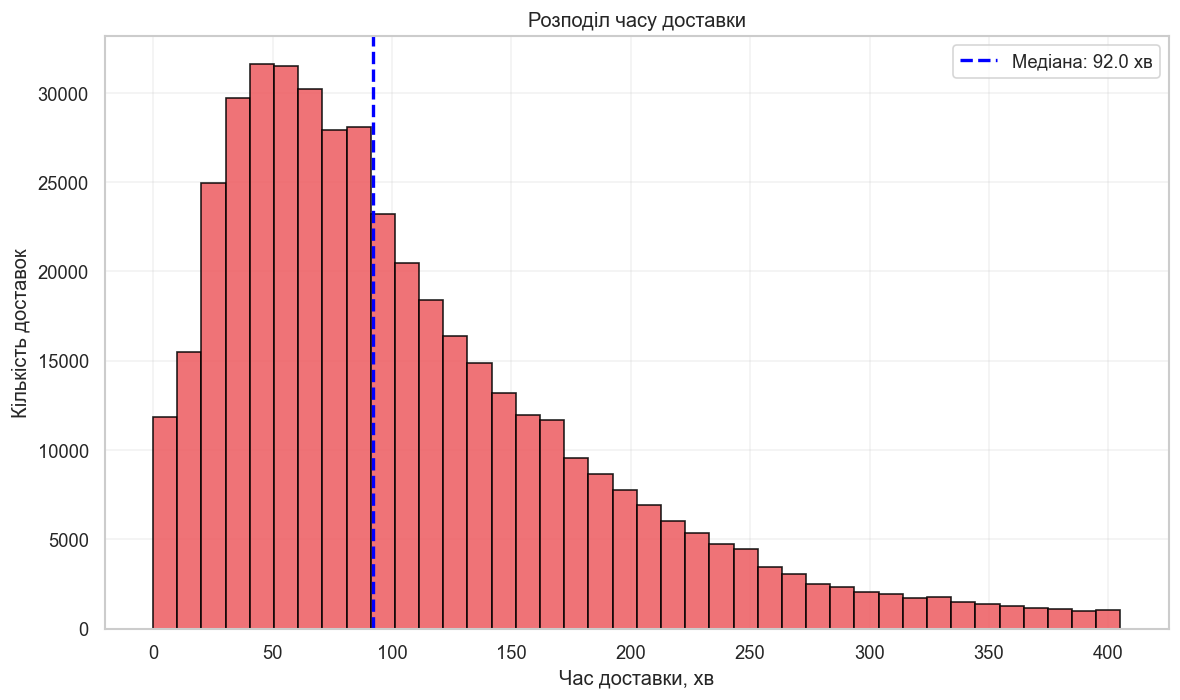

In [ ]:
plot_data = df[
    df["delivery_duration_min"] <= df["delivery_duration_min"].quantile(0.95)
].copy()

plt.figure()

plt.hist(
    plot_data["delivery_duration_min"],
    bins=40,
    color=cmap(0.65),
    edgecolor="black",
    alpha=0.85
)

median_time = df["delivery_duration_min"].median()

plt.axvline(
    median_time,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Медіана: {median_time:.1f} хв"
)

plt.legend()

plt.title("Розподіл часу доставки")

plt.xlabel("Час доставки, хв")

plt.ylabel("Кількість доставок")

plt.tight_layout()

plt.show()

Пояснює форму розподілу: концентрацію масиву в основній зоні та наявність правого “хвоста”. Це добра візуалізація для обґрунтування медіани і порогового аналізу.

Висновок

Більшість доставок виконуються у проміжку приблизно від 30 до 120 хвилин.

Також на графіку видно, що існує значна кількість довгих доставок, час яких перевищує 200–300 хвилин.
Це свідчить про наявність затримок та нерівномірності у процесі доставки.

Розподіл має зміщення вправо, тобто окремі доставки займають значно більше часу за середній показник.


# 8. KDE PLOT BY CITY

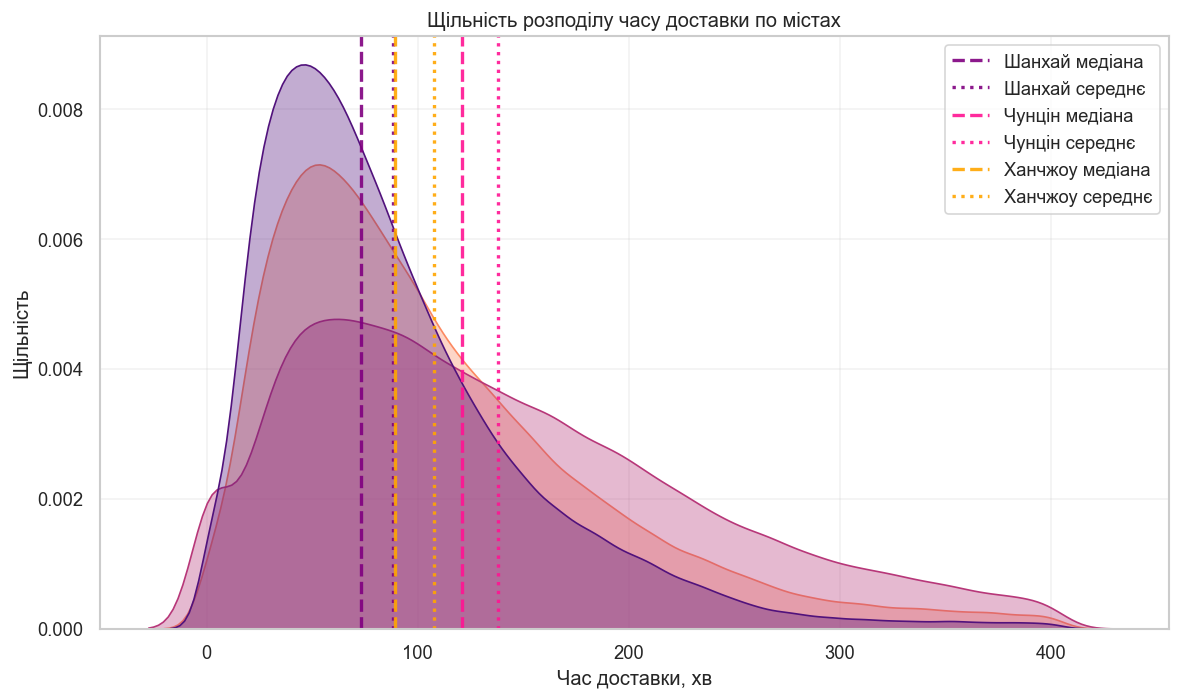

In [ ]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=plot_data,
    x="delivery_duration_min",
    hue="city_ua",
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette="magma"
)

# Медіана та середнє по містах
for city, color in zip(
    ["Шанхай", "Чунцін", "Ханчжоу"],
    ["purple", "deeppink", "orange"]
):

    city_data = plot_data[
        plot_data["city_ua"] == city
    ]["delivery_duration_min"]

    # Медіана
    median_value = city_data.median()

    plt.axvline(
        median_value,
        color=color,
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"{city} медіана"
    )

    # Середнє значення
    mean_value = city_data.mean()

    plt.axvline(
        mean_value,
        color=color,
        linestyle=":",
        linewidth=2,
        alpha=0.9,
        label=f"{city} середнє"
    )

plt.title("Щільність розподілу часу доставки по містах")

plt.xlabel("Час доставки, хв")

plt.ylabel("Щільність")

plt.legend()

plt.tight_layout()

plt.show()

Дозволяє порівняти щільність розподілу між містами не лише за центром, а й за шириною та довгим хвостом.

KDE plot by city
Висновок

Графік показує, що у Шанхаї більшість доставок виконуються швидше та більш стабільно.

У Ханчжоу розподіл є ширшим, що свідчить про більшу варіативність часу доставки.

У Чунціні спостерігається найбільша кількість довгих доставок, а також найбільший розкид значень часу доставки.
Це може бути пов’язано зі складнішою транспортною ситуацією або менш ефективною організацією маршрутів.


# 9. AVERAGE DELIVERY TIME BY CITY


In [27]:
# AVERAGE DELIVERY TIME BY CITY

city_delivery_stats = (
    df.groupby("city_ua")["delivery_duration_min"]
    .agg(
        average_delivery_time="mean",
        standard_deviation="std",
        variance="var"
    )
    .round(2)
    .reset_index()
)

display(city_delivery_stats)

city_duration = (
    df.groupby("city_ua")["delivery_duration_min"]
    .mean()
    .round(2)
    .sort_values()
)

city_kpi_table = pd.DataFrame({
    "Місто": city_duration.index,
    "Середній час доставки, хв": city_duration.values
})

display(city_kpi_table)

,city_ua,average_delivery_time,standard_deviation,variance
0,Ханчжоу,127.55,129.11,16670.01
1,Чунцін,192.62,188.13,35391.51
2,Шанхай,96.51,95.13,9049.82


,Місто,"Середній час доставки, хв"
0,Шанхай,96.51
1,Ханчжоу,127.55
2,Чунцін,192.62


Проведений аналіз середнього часу доставки по містах показав не лише різницю у швидкості доставки, а й рівень стабільності логістичних процесів. Для цього додатково були розраховані стандартне відхилення та дисперсія часу доставки.

Отримані результати свідчать, що в окремих містах час доставки суттєво коливається. Зокрема, високі значення стандартного відхилення вказують на нестабільність доставки та значну різницю між окремими замовленнями. Це може бути пов’язано з дорожньою ситуацією, навантаженням на кур’єрів, особливостями міської інфраструктури або нерівномірним розподілом замовлень.

Найбільш стабільні показники доставки спостерігаються у містах із меншим стандартним відхиленням, де фактичний час доставки є більш передбачуваним. Водночас міста з високою варіативністю часу доставки можуть потребувати додаткової оптимізації логістичних процесів.

Таким чином, використання стандартного відхилення та дисперсії дозволило не лише оцінити середній час доставки, а й проаналізувати стабільність та передбачуваність роботи служби доставки в різних містах.


Дозволяє порівняти щільність розподілу між містами не лише за центром, а й за шириною та довгим хвостом.

,Місто,"Середній час доставки, хв"
0,Шанхай,96.51
1,Ханчжоу,127.55
2,Чунцін,192.62


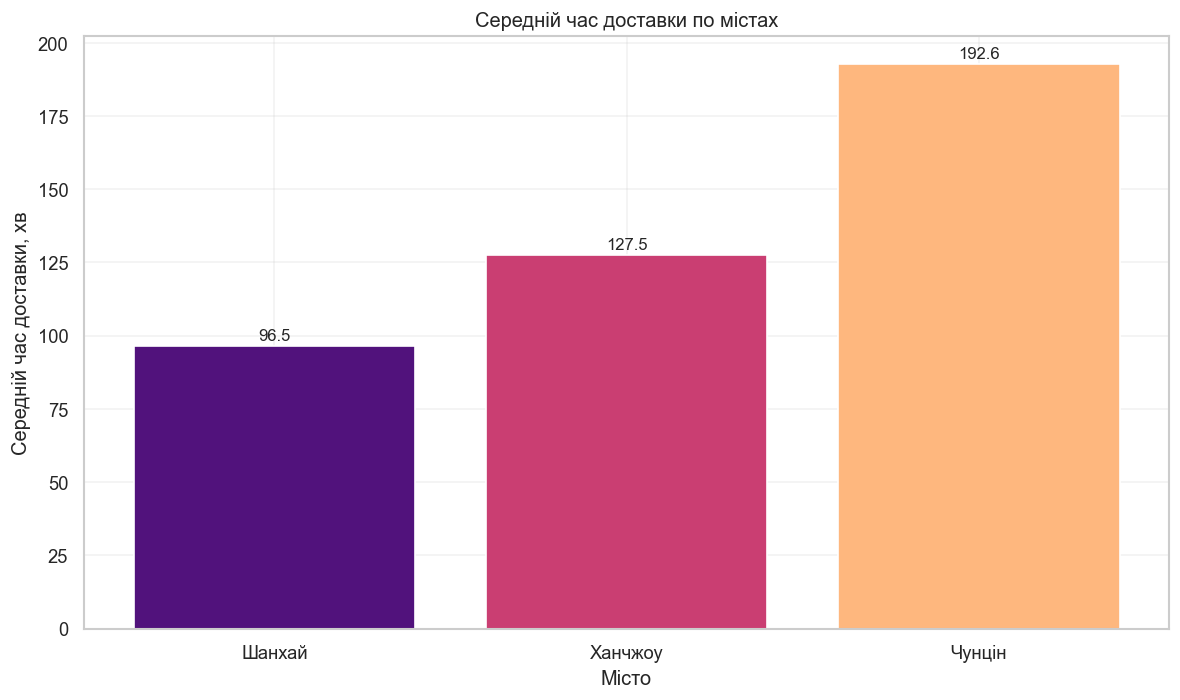

In [28]:
# AVERAGE DELIVERY TIME BY CITY

city_duration = (
    df.groupby("city_ua")["delivery_duration_min"]
    .mean()
    .round(2)
    .sort_values()
)

city_kpi_table = pd.DataFrame({
    "Місто": city_duration.index,
    "Середній час доставки, хв": city_duration.values
})

display(city_kpi_table)

plt.figure()
colors = get_magma_colors(len(city_duration))

bars = plt.bar(
    city_duration.index,
    city_duration.values,
    color=colors
)

plt.title("Середній час доставки по містах")
plt.xlabel("Місто")
plt.ylabel("Середній час доставки, хв")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{height:.1f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Середній час доставки по містах
Висновок

Найменший середній час доставки спостерігається у Шанхаї — 96,5 хв.

У Ханчжоу середній час доставки є вищим і становить 127,5 хв.

Найбільший середній час доставки зафіксований у Чунціні — 192,6 хв, що майже у два рази більше порівняно із Шанхаєм.

Отримані результати підтверджують, що саме Чунцін є найбільш проблемним містом з точки зору ефективності доставки.


# 10. BOXPLOT OF DELIVERY TIME BY CITY

C:\Users\Dell\AppData\Local\Temp\ipykernel_3152\1072173066.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


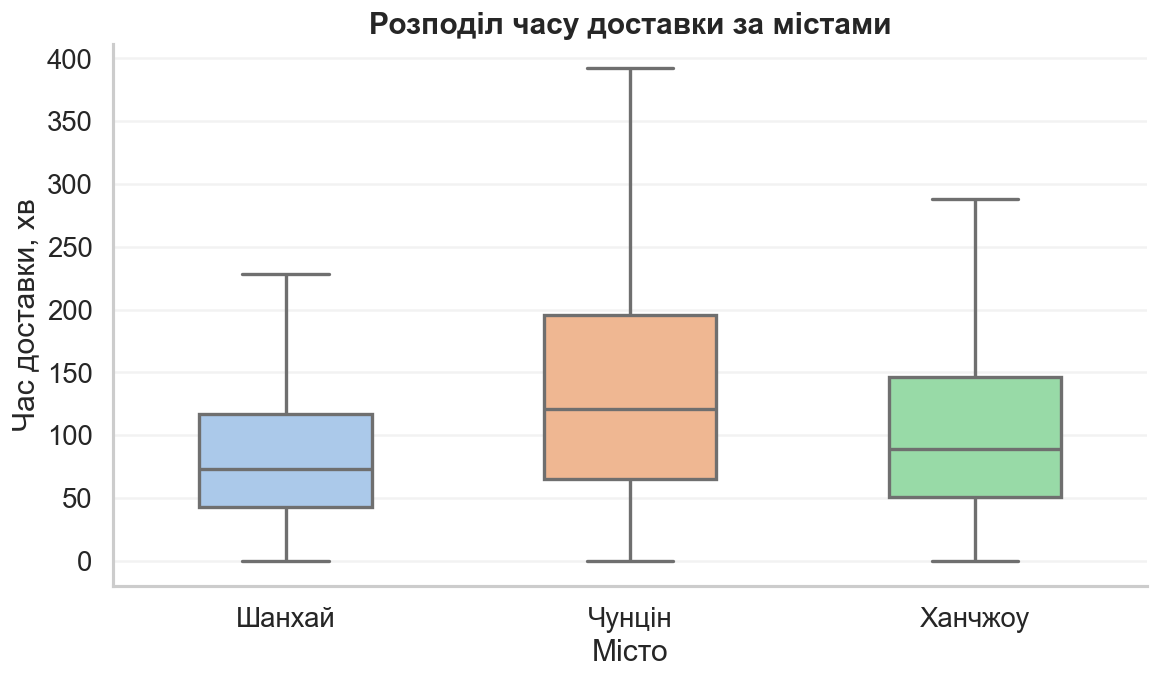

In [ ]:
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=plot_data,
    x="city_ua",
    y="delivery_duration_min",
    palette="pastel",
    width=0.5,
    showfliers=False,
    linewidth=2
)

plt.title(
    "Розподіл часу доставки за містами",
    fontsize=18,
    weight='bold'
)

plt.xlabel("Місто")
plt.ylabel("Час доставки, хв")

sns.despine()

plt.tight_layout()
plt.show()

Показує медіану, міжквартильний розмах і загальну стабільність. Його треба коментувати саме через варіативність, а не тільки через середнє.

Висновок

Графік показує, що у Шанхаї доставка є найбільш стабільною та передбачуваною — більшість замовлень виконуються за відносно короткий час.

У Ханчжоу спостерігається більший розкид часу доставки, тобто окремі доставки можуть виконуватись значно довше.

Найбільший розкид часу доставки зафіксовано у Чунціні. Це свідчить про те, що у цьому місті процес доставки працює менш стабільно та має більше затримок.


# 11. PREPARE COORDINATES FOR MAP

In [ ]:


# У LaDe координати збережені у збільшеному масштабі, тому ділимо на 100000
df["receipt_lng_clean"] = df["receipt_lng"] / 100000
df["receipt_lat_clean"] = df["receipt_lat"] / 100000
df["poi_lng_clean"] = df["poi_lng"] / 100000
df["poi_lat_clean"] = df["poi_lat"] / 100000

# Перевірка координат
coordinate_check = df[
    [
        "city_ua",
        "receipt_lng_clean",
        "receipt_lat_clean",
        "poi_lng_clean",
        "poi_lat_clean",
        "delivery_duration_min"
    ]
].head()

display(coordinate_check)

,city_ua,receipt_lng_clean,receipt_lat_clean,poi_lng_clean,poi_lat_clean,delivery_duration_min
0,Шанхай,105.616034,-74.579978,105.635125,-74.583210,76.0
1,Чунцін,89.009915,-76.861034,88.998739,-76.849363,361.0
2,Шанхай,105.812446,-74.676066,105.813058,-74.673970,152.0
3,Шанхай,105.616045,-74.579965,105.627277,-74.568042,117.0
5,Шанхай,105.667062,-74.850634,105.642884,-74.853000,36.0



# 12. PROBLEM DELIVERIES


Тут ми визначаємо проблемні доставки як ті, що тривають понад 180 хвилин.

In [ ]:


problem_threshold = 180

df["is_problem_delivery"] = df["delivery_duration_min"] > problem_threshold

problem_summary = (
    df.groupby("city_ua")
    .agg(
        total_deliveries=("order_id", "count"),
        problem_deliveries=("is_problem_delivery", "sum"),
        avg_delivery_time=("delivery_duration_min", "mean"),
        median_delivery_time=("delivery_duration_min", "median")
    )
    .reset_index()
)

problem_summary["problem_share_%"] = (
    problem_summary["problem_deliveries"] 
    / problem_summary["total_deliveries"] 
    * 100
).round(2)

problem_summary["avg_delivery_time"] = problem_summary["avg_delivery_time"].round(2)
problem_summary["median_delivery_time"] = problem_summary["median_delivery_time"].round(2)

problem_summary = problem_summary.sort_values("problem_share_%", ascending=False)

display(problem_summary)

,city_ua,total_deliveries,problem_deliveries,avg_delivery_time,median_delivery_time,problem_share_%
1,Чунцін,115990,43395,192.62,138.0,37.41
0,Ханчжоу,184346,35368,127.55,92.0,19.19
2,Шанхай,165048,17280,96.51,74.0,10.47


проблемними вважаються доставки понад 180 хв. Саме ця візуалізація переводить аналіз у площину надійності сервісу.

Висновок

Найбільша частка проблемних доставок спостерігається у Чунціні — 37,4% доставок тривають понад 180 хвилин.

У Ханчжоу частка проблемних доставок становить 19,2%, що майже вдвічі менше.

Найкраща ситуація спостерігається у Шанхаї, де лише 10,5% доставок перевищують 180 хвилин.

Отримані результати підтверджують, що саме Чунцін є найбільш проблемним містом з точки зору ефективності транспортно-технологічного процесу доставки.


# 13. PROBLEM DELIVERY SHARE BY CITY

# Візуалізація частки проблемних доставок


C:\Users\Dell\AppData\Local\Temp\ipykernel_3152\64868506.py:4: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


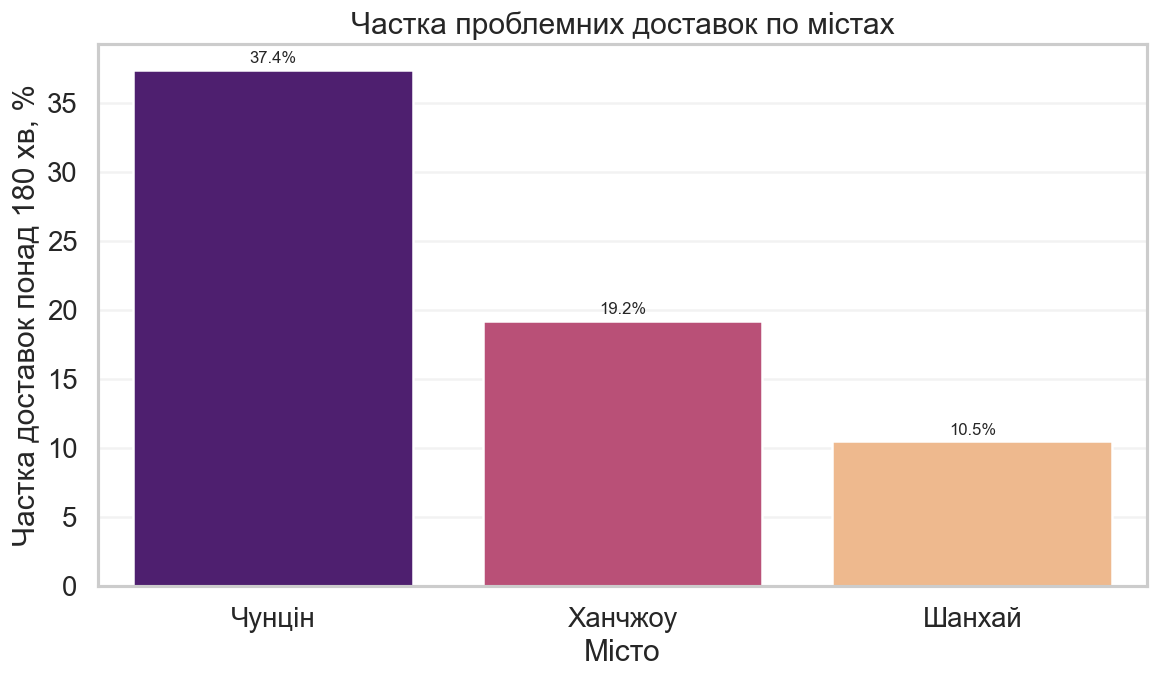

In [ ]:

plt.figure()
colors = get_magma_colors(len(problem_summary))

sns.barplot(
    data=problem_summary,
    x="city_ua",
    y="problem_share_%",
    hue="city_ua",
    palette=colors,
    legend=False
)

plt.title("Частка проблемних доставок по містах")
plt.xlabel("Місто")
plt.ylabel("Частка доставок понад 180 хв, %")

for index, row in problem_summary.reset_index(drop=True).iterrows():
    plt.text(
        index,
        row["problem_share_%"] + 0.5,
        f"{row['problem_share_%']:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Дає змогу порівняти міста не за середнім часом, а за частотою порушення обраного сервісного стандарту.


# 14. STACKED BAR CHART BY CITY


delivery_category,До 60 хв,60–180 хв,Понад 180 хв
city_ua,,,
Ханчжоу,56053,92925,35368
Чунцін,23593,49002,43395
Шанхай,65521,82247,17280


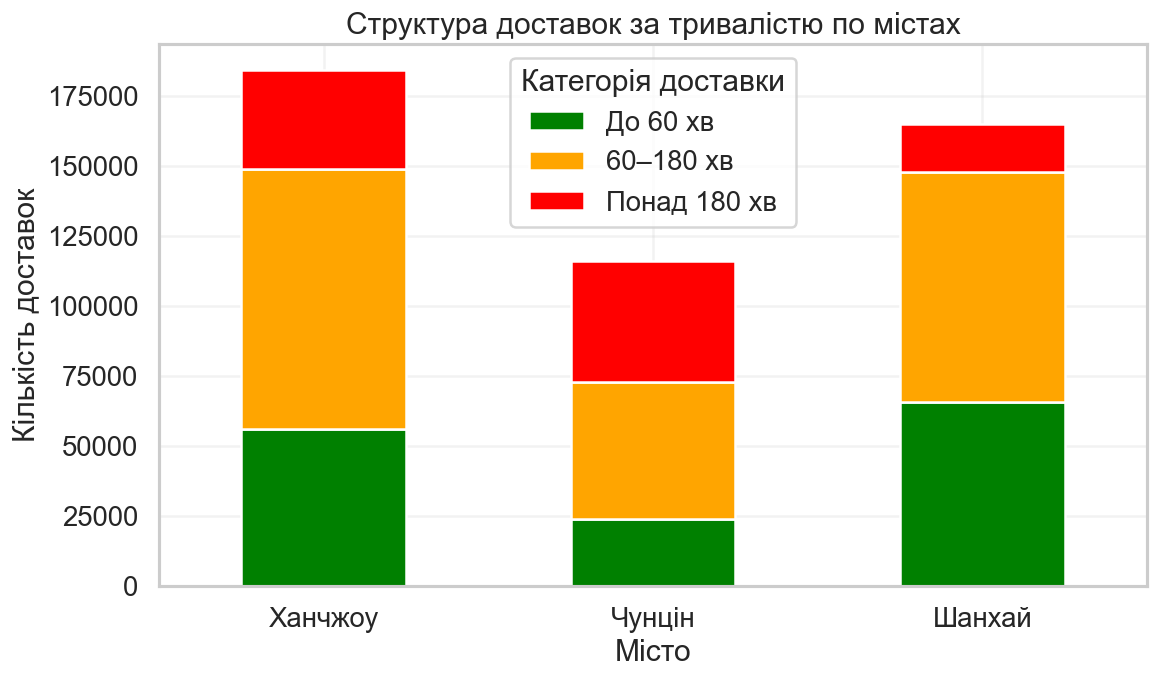

In [ ]:


delivery_categories = df.copy()

delivery_categories["delivery_category"] = pd.cut(
    delivery_categories["delivery_duration_min"],
    bins=[0, 60, 180, 1440],
    labels=[
        "До 60 хв",
        "60–180 хв",
        "Понад 180 хв"
    ],
    include_lowest=True
)

stacked_data = (
    delivery_categories
    .groupby(["city_ua", "delivery_category"], observed=True)
    .size()
    .unstack(fill_value=0)
)

display(stacked_data)

stacked_data.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["green", "orange", "red"]
)

plt.title("Структура доставок за тривалістю по містах")

plt.xlabel("Місто")

plt.ylabel("Кількість доставок")

plt.legend(title="Категорія доставки")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()


# 15. PROBLEM DELIVERY MAPS BY CITY


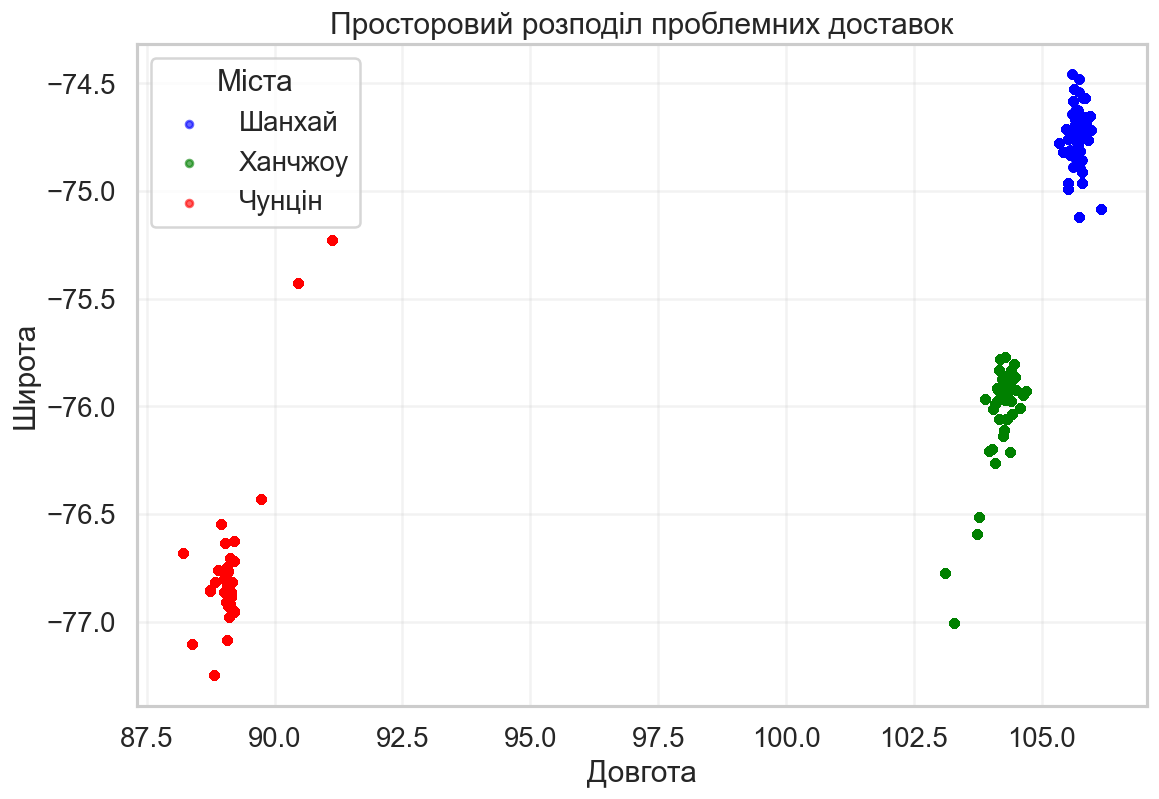

In [ ]:

# COMBINED PROBLEM DELIVERY MAP

problem_map_data = df[
    df["is_problem_delivery"] == True
].copy()

plt.figure(figsize=(10,7))

# Шанхай
shanghai = problem_map_data[
    problem_map_data["city_ua"] == "Шанхай"
]

plt.scatter(
    shanghai["receipt_lng_clean"],
    shanghai["receipt_lat_clean"],
    color="blue",
    alpha=0.6,
    s=18,
    label="Шанхай"
)

# Ханчжоу
hangzhou = problem_map_data[
    problem_map_data["city_ua"] == "Ханчжоу"
]

plt.scatter(
    hangzhou["receipt_lng_clean"],
    hangzhou["receipt_lat_clean"],
    color="green",
    alpha=0.6,
    s=18,
    label="Ханчжоу"
)

# Чунцін
chongqing = problem_map_data[
    problem_map_data["city_ua"] == "Чунцін"
]

plt.scatter(
    chongqing["receipt_lng_clean"],
    chongqing["receipt_lat_clean"],
    color="red",
    alpha=0.6,
    s=18,
    label="Чунцін"
)

plt.title("Просторовий розподіл проблемних доставок")

plt.xlabel("Довгота")

plt.ylabel("Широта")

plt.legend(title="Міста")

plt.tight_layout()

plt.show()

# АНАЛІЗ ЕФЕКТИВНОСТІ КУР’ЄРІВ

 # ЧОМУ ЦЕ ДУЖЕ ВАЖЛИВО
 
## Бо це вже:

логістика;
управління доставкою;
routing efficiency;
workload balancing.


# 16. COURIER WORKLOAD ANALYSIS
# КІЛЬКІСТЬ ДОСТАВОК КУР'ЄІВ

In [ ]:


courier_orders = (
    df.groupby("delivery_user_id")
    .agg(
        total_deliveries=("order_id", "count"),
        avg_delivery_time=("delivery_duration_min", "mean")
    )
    .reset_index()
)

courier_orders["avg_delivery_time"] = (
    courier_orders["avg_delivery_time"]
    .round(2)
)

display(courier_orders.head())

,delivery_user_id,total_deliveries,avg_delivery_time
0,0008c2b6a2314db8715301b7eeeebc5a,116,220.67
1,000e98aedd35d5e6b671144eff2975bb,1,188.00
2,0018c46d0ac8c065ffd9b2588f135d5b,32,102.19
3,00230f9acdd3b69b47639b261ef7d3f4,347,94.99
4,00394bab2f015247df56eb56b9a9dd6a,450,173.24


Дає змогу порівняти міста не за середнім часом, а за частотою порушення обраного сервісного стандарту.


# 17. TOP COURIERS BAR CHART


In [ ]:
# TOP COURIERS DATA

top_couriers = (
    courier_orders
    .sort_values("total_deliveries", ascending=False)
    .head(15)
)

display(top_couriers)

,delivery_user_id,total_deliveries,avg_delivery_time
956,7d66d344ae85a711b07d28ffbe6544df,940,78.28
272,26ba716fbe642f583566393fb7af4d22,922,101.71
1709,ec735deb7c9fa7d3989d25fc456dd735,901,235.70
995,82f64408204eaf2ca904383822b55d30,875,148.28
1207,a15bf2b06c3f6f42b87cb4a9528a9c39,846,113.14
688,5cd356d5b23e7eb9f3d8c946b1a7fe0a,811,129.25
1591,d9eb419030a7b49b9dfdef9fa8e03c8d,808,131.98
701,5e2c4e5d0520dc8a358de43fe8c0d820,796,67.38
1545,d38aeae15031dbe314381187733fe8f4,791,54.09
703,5e57d925f07bd96d4919d4db7befb891,780,167.71


C:\Users\Dell\AppData\Local\Temp\ipykernel_3152\374107310.py:20: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


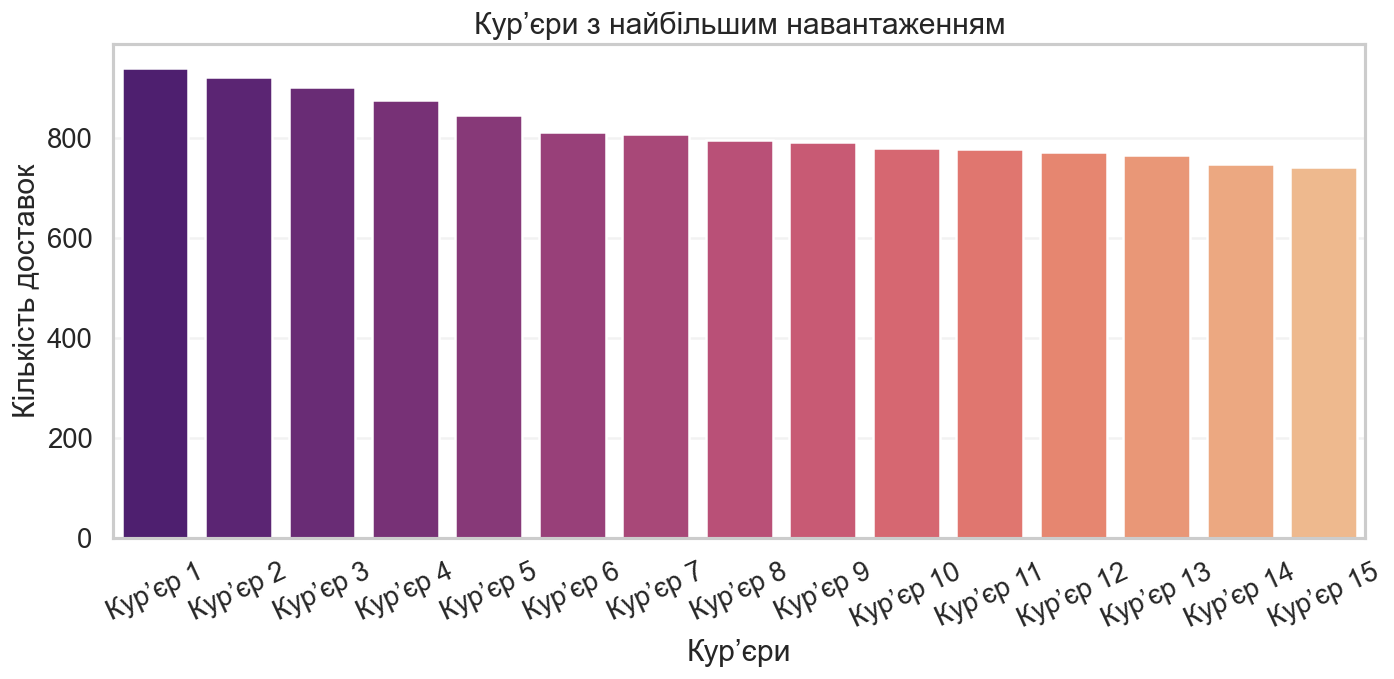

In [ ]:
# TOP COURIERS DATA

top_couriers = (
    courier_orders
    .sort_values("total_deliveries", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

# Створюємо умовні назви кур’єрів
top_couriers["courier_label"] = [
    f"Кур’єр {i+1}" for i in range(len(top_couriers))
]

# Побудова графіка
plt.figure(figsize=(12,6))

colors = get_magma_colors(len(top_couriers))

sns.barplot(
    data=top_couriers,
    x="courier_label",
    y="total_deliveries",
    hue="courier_label",
    palette=colors,
    legend=False
)

plt.title("Кур’єри з найбільшим навантаженням")

plt.xlabel("Кур’єри")

plt.ylabel("Кількість доставок")

plt.xticks(rotation=25)

plt.tight_layout()

plt.show()


# 18 WORKLOAD VS DELIVERY TIME
# ЧИ ВПЛИВАЄ НАВАНТАЖЕННЯ НА ЧАС ДОСТАВКИ

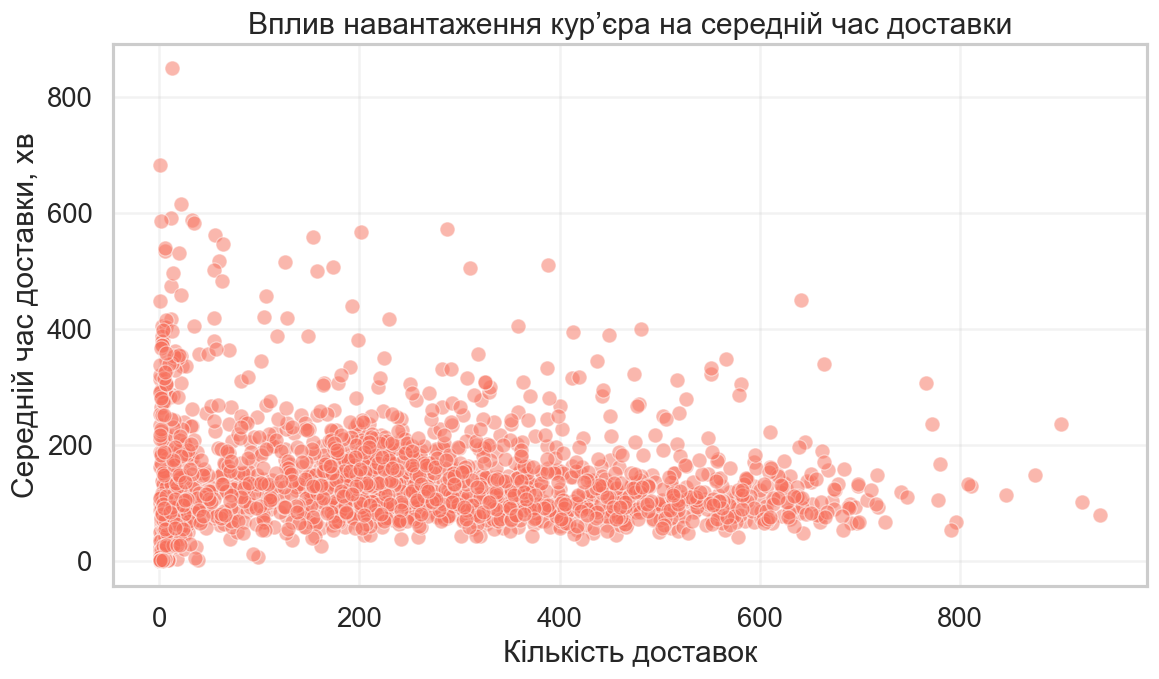

In [ ]:


plt.figure(figsize=(10,6))

sns.scatterplot(
    data=courier_orders,
    x="total_deliveries",
    y="avg_delivery_time",
    color=cmap(0.7),
    alpha=0.5
)

plt.title("Вплив навантаження кур’єра на середній час доставки")

plt.xlabel("Кількість доставок")

plt.ylabel("Середній час доставки, хв")

plt.tight_layout()

plt.show()

Для дослідження було проаналізовано вплив навантаження кур’єрів на середній час доставки.

Отримані результати показали, що чіткої прямої залежності між кількістю доставок та середнім часом доставки не спостерігається. Більшість кур’єрів виконують доставку в межах 50–200 хв незалежно від навантаження.

Разом із цим у dataset присутні окремі випадки дуже тривалих доставок, які можуть бути пов’язані зі складними маршрутами, заторами, великою відстанню доставки або неефективною організацією процесу доставки.

Також можна помітити, що кур’єри з найбільшим навантаженням часто мають більш стабільний середній час доставки, що може свідчити про кращу оптимізацію маршрутів або вищий рівень досвіду кур’єрів.
